In [82]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
KAGGLE_INPUT = Path("/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset")

print("Available datasets:")
for item in KAGGLE_INPUT.iterdir():
    print(item)

Available datasets:
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/test
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/train


In [6]:
DATASET_DIR = Path("/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset")

train_dir = DATASET_DIR / "train"
val_dir = DATASET_DIR / "val"
test_dir = DATASET_DIR / "test"

print("Train path:", train_dir)
print("Validation path:", val_dir)
print("Test path:", test_dir)

print("\nChecking paths:")
print("Train exists:", train_dir.exists())
print("Validation exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

Train path: /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/train
Validation path: /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val
Test path: /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/test

Checking paths:
Train exists: True
Validation exists: True
Test exists: True


In [7]:
classes = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))

print("\nVehicle Color Classes:")
for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

Number of classes: 15

Vehicle Color Classes:
0: beige
1: black
2: blue
3: brown
4: gold
5: green
6: grey
7: orange
8: pink
9: purple
10: red
11: silver
12: tan
13: white
14: yellow


In [8]:
class_counts = {}

for class_name in classes:
    class_path = train_dir / class_name
    
    image_count = len([
        file for file in class_path.iterdir()
        if file.is_file()
    ])
    
    class_counts[class_name] = image_count

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Color", "Image Count"]
)

class_counts_df

,Color,Image Count
0,beige,421
1,black,406
2,blue,742
3,brown,565
4,gold,210
5,green,563
6,grey,428
7,orange,534
8,pink,483
9,purple,536


In [9]:
total_train_images = class_counts_df["Image Count"].sum()

print("Total training images:", total_train_images)

Total training images: 7267


In [10]:
def count_images(folder):
    total = 0
    
    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            total += len([
                file for file in class_folder.iterdir()
                if file.is_file()
            ])
    
    return total


total_val_images = count_images(val_dir)
total_test_images = count_images(test_dir)

print("Training images  :", total_train_images)
print("Validation images:", total_val_images)
print("Test images      :", total_test_images)

Training images  : 7267
Validation images: 1550
Test images      : 1556


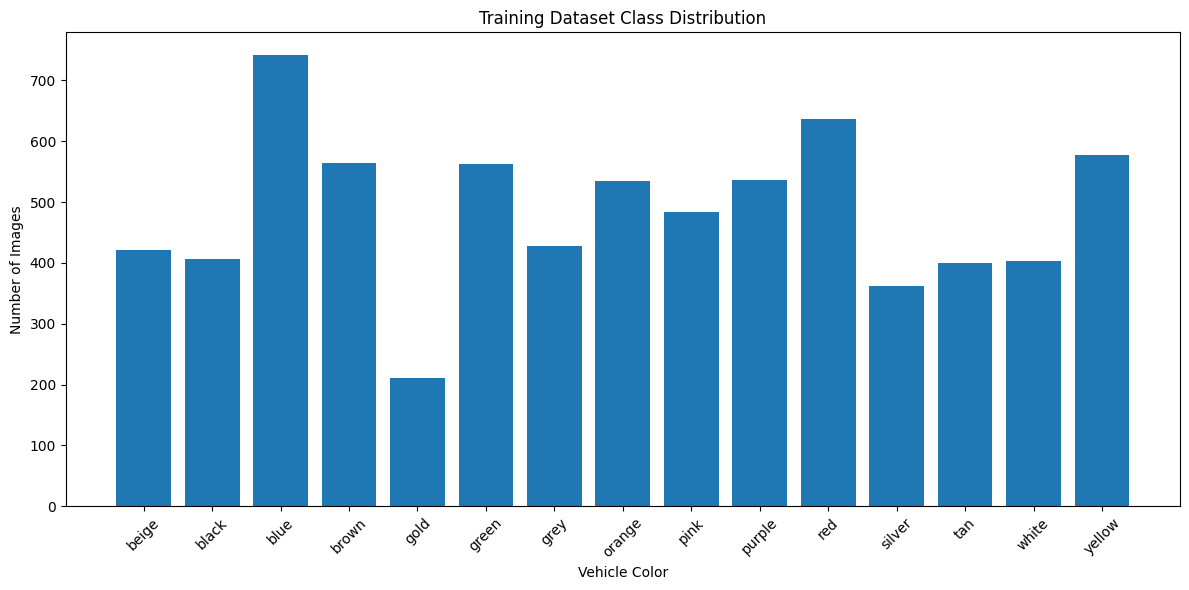

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_counts_df["Color"],
    class_counts_df["Image Count"]
)

plt.xlabel("Vehicle Color")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

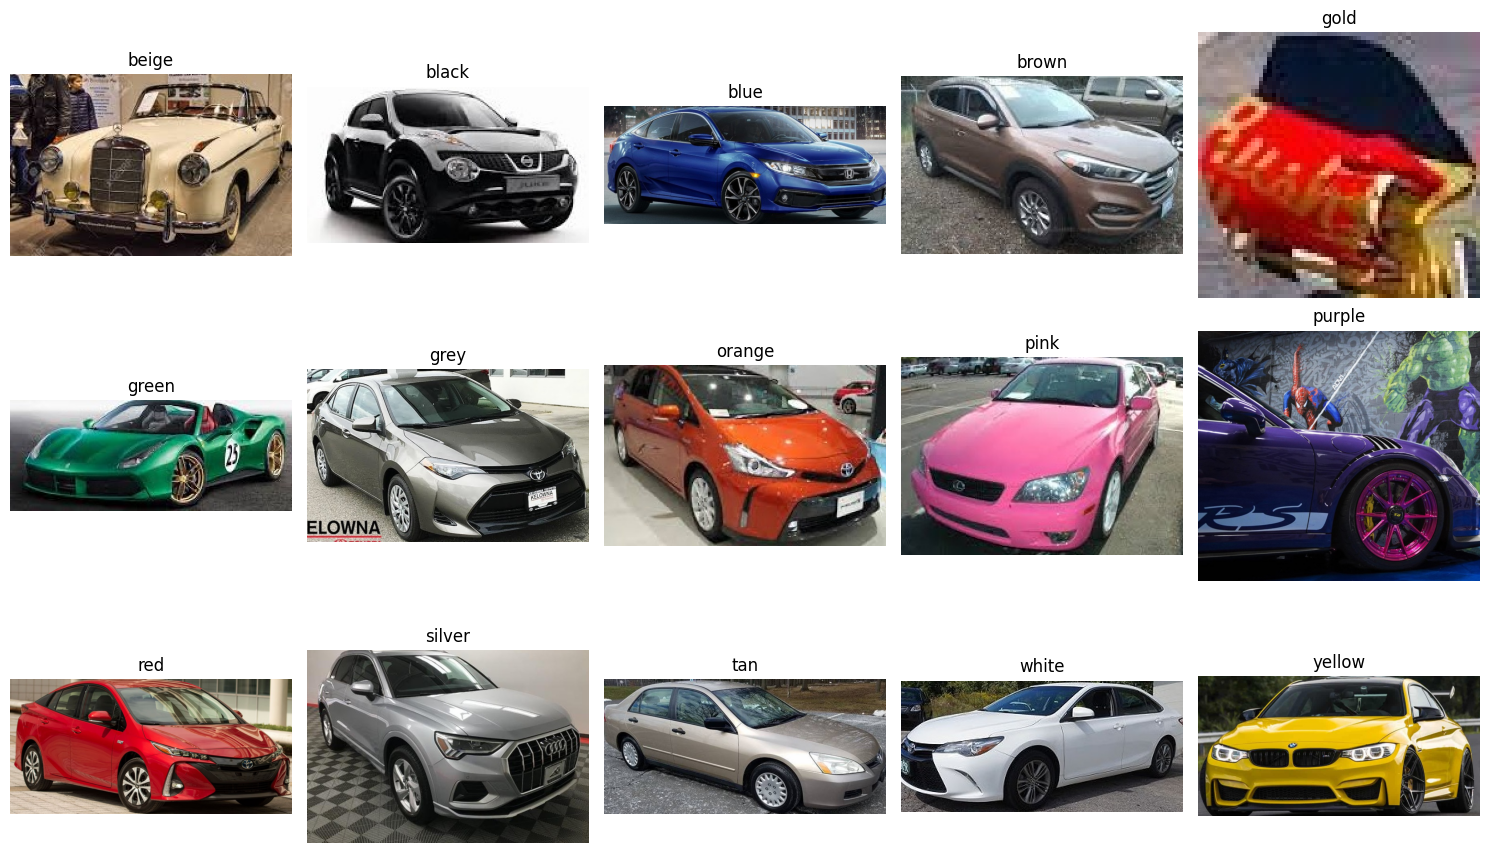

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, class_name in zip(axes.flatten(), classes):
    
    class_path = train_dir / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.is_file()
    ]
    
    if image_files:
        image_path = image_files[0]
        
        with Image.open(image_path) as image:
            image = image.convert("RGB")
        
        ax.imshow(image)
        ax.set_title(class_name)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
sample_sizes = []

for class_name in classes:
    class_path = train_dir / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.is_file()
    ]
    
    for image_path in image_files[:10]:
        try:
            with Image.open(image_path) as img:
                sample_sizes.append(img.size)
        except Exception:
            pass

print("Number of sampled images:", len(sample_sizes))
print("First 20 image sizes:")
print(sample_sizes[:20])

Number of sampled images: 150
First 20 image sizes:
[(257, 165), (607, 414), (463, 326), (221, 93), (194, 147), (226, 108), (1238, 692), (567, 360), (199, 92), (366, 223), (212, 118), (234, 126), (834, 391), (171, 140), (217, 114), (268, 197), (224, 120), (171, 85), (239, 106), (936, 341)]


In [22]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [23]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Training dataset loaded.")

Found 7267 files belonging to 15 classes.


I0000 00:00:1788943645.687055      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788943645.690344      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training dataset loaded.


In [24]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation dataset loaded.")

Found 1550 files belonging to 15 classes.
Validation dataset loaded.


In [25]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset loaded.")

Found 1556 files belonging to 15 classes.
Test dataset loaded.


In [26]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))

print("\nClasses:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Number of classes: 15

Classes:
0: beige
1: black
2: blue
3: brown
4: gold
5: green
6: grey
7: orange
8: pink
9: purple
10: red
11: silver
12: tan
13: white
14: yellow


In [27]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First 10 labels: [ 0 12  5  7 14  0  3  1  7 10]


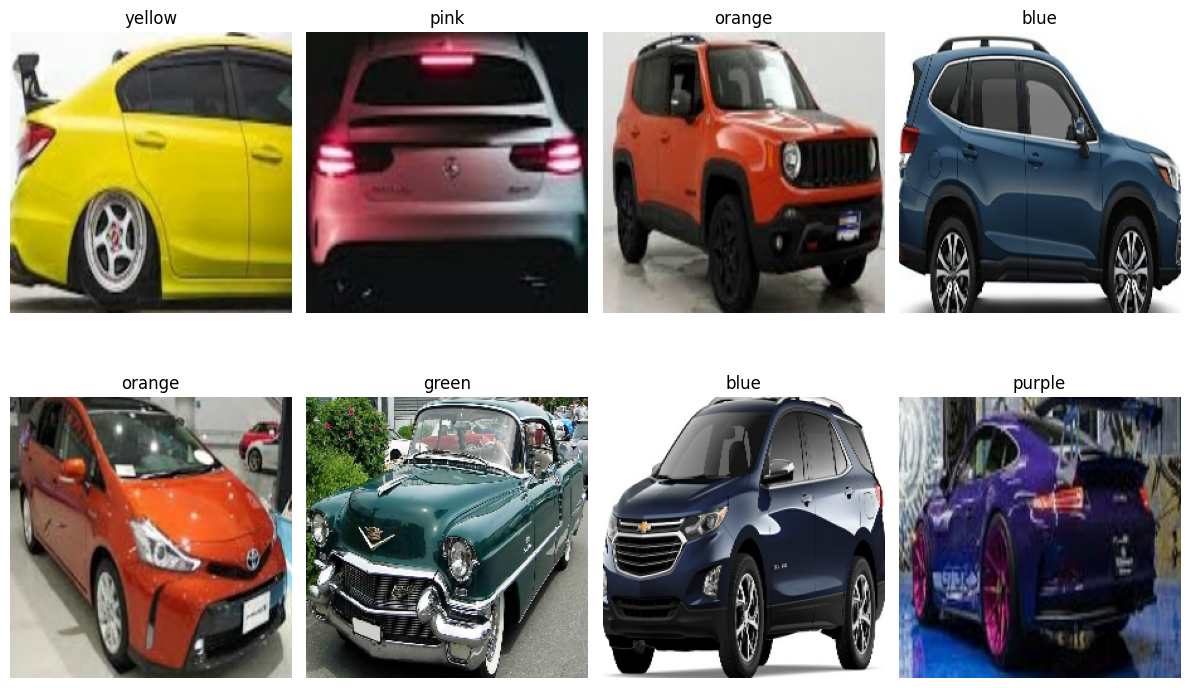

In [28]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


In [30]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


In [62]:
num_classes = len(class_names)
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values: 0-255 → 0-1
    layers.Rescaling(1.0 / 255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

print("Fresh CNN created.")

model.summary()

Fresh CNN created.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 425,167 (1.62 MB)

 Trainable params: 424,207 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [63]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [64]:

Model_path = "/kaggle/working/vehicle_color_model.h5"
print("Model will be saved at:")
print(Model_path)

Model will be saved at:
/kaggle/working/vehicle_color_model.h5


In [65]:
earlystopping = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

model_checkpoint = ModelCheckpoint(
    Model_path,
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [66]:
epochs = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[
        earlystopping,
        model_checkpoint,
        reduce_lr
    ]
)

Epoch 1/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4722 - loss: 1.6467
Epoch 1: val_accuracy improved from None to 0.10452, saving model to /kaggle/working/vehicle_color_model.h5



Epoch 1: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - accuracy: 0.5470 - loss: 1.3781 - val_accuracy: 0.1045 - val_loss: 4.1293 - learning_rate: 0.0010
Epoch 2/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6286 - loss: 1.1364
Epoch 2: val_accuracy improved from 0.10452 to 0.58000, saving model to /kaggle/working/vehicle_color_model.h5



Epoch 2: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.6327 - loss: 1.1126 - val_accuracy: 0.5800 - val_loss: 1.2314 - learning_rate: 0.0010
Epoch 3/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6582 - loss: 1.0334
Epoch 3: val_accuracy improved from 0.58000 to 0.62129, saving model to /kaggle/working/vehicle_color_model.h5



Epoch 3: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.6666 - loss: 0.9900 - val_accuracy: 0.6213 - val_loss: 1.2366 - learning_rate: 0.0010
Epoch 4/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6831 - loss: 0.9708
Epoch 4: val_accuracy improved from 0.62129 to 0.68323, saving model to /kaggle/working/vehicle_color_model.h5



Epoch 4: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.6854 - loss: 0.9466 - val_accuracy: 0.6832 - val_loss: 0.9447 - learning_rate: 0.0010
Epoch 5/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6811 - loss: 0.9502
Epoch 5: val_accuracy did not improve from 0.68323
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.6898 - loss: 0.9128 - val_accuracy: 0.5632 - val_loss: 1.7108 - learning_rate: 0.0010
Epoch 6/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7102 - loss: 0.8794
Epoch 6: val_accuracy improved from 0.68323 to 0.70774, saving model to /kaggle/working/vehicle_color_model.h5


...


Epoch 17: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7789 - loss: 0.6378 - val_accuracy: 0.7994 - val_loss: 0.5397 - learning_rate: 1.2500e-04
Epoch 18/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7800 - loss: 0.6499
Epoch 18: val_accuracy did not improve from 0.79935
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7862 - loss: 0.6271 - val_accuracy: 0.7890 - val_loss: 0.5991 - learning_rate: 1.2500e-04
Epoch 19/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7800 - loss: 0.6317
Epoch 19: val_accuracy did not improve from 0.79935

Epoch 19: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7801 - loss: 0.6257 - val_accuracy: 0.7961 - val_loss: 0.5581 - learning_rate: 1.2500e-04
Epoch 20/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7858 - loss: 0.6111
Epoch 20: val_accuracy improved f


Epoch 20: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7907 - loss: 0.6047 - val_accuracy: 0.8077 - val_loss: 0.5335 - learning_rate: 6.2500e-05
Epoch 21/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7930 - loss: 0.6171
Epoch 21: val_accuracy did not improve from 0.80774
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7899 - loss: 0.6013 - val_accuracy: 0.8052 - val_loss: 0.5448 - learning_rate: 6.2500e-05
Epoch 22/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7855 - loss: 0.6182
Epoch 22: val_accuracy did not improve from 0.80774
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7912 - loss: 0.6043 - val_accuracy: 0.8013 - val_loss: 0.5281 - learning_rate: 6.2500e-05
Epoch 23/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7864 - loss: 0.6243
Epoch 23: val_accuracy did not improve from 0.80774
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.


Epoch 26: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7932 - loss: 0.5872 - val_accuracy: 0.8097 - val_loss: 0.5264 - learning_rate: 3.1250e-05
Epoch 27/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7936 - loss: 0.5934
Epoch 27: val_accuracy did not improve from 0.80968
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7932 - loss: 0.5905 - val_accuracy: 0.8084 - val_loss: 0.5168 - learning_rate: 3.1250e-05
Epoch 28/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7840 - loss: 0.5891
Epoch 28: val_accuracy did not improve from 0.80968
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7895 - loss: 0.5825 - val_accuracy: 0.8058 - val_loss: 0.5255 - learning_rate: 3.1250e-05
Epoch 29/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7882 - loss: 0.6130
Epoch 29: val_accuracy did not improve from 0.80968

Epoch 29: ReduceLROnPlateau reducing learning rate to 1.5


Epoch 30: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.8021 - loss: 0.5739 - val_accuracy: 0.8161 - val_loss: 0.5172 - learning_rate: 1.5625e-05
Epoch 31/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7937 - loss: 0.6088
Epoch 31: val_accuracy did not improve from 0.81613
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7958 - loss: 0.5881 - val_accuracy: 0.8135 - val_loss: 0.5161 - learning_rate: 1.5625e-05
Epoch 32/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7946 - loss: 0.5754
Epoch 32: val_accuracy improved from 0.81613 to 0.81677, saving model to /kaggle/working/vehicle_color_model.h5



Epoch 32: finished saving model to /kaggle/working/vehicle_color_model.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.7972 - loss: 0.5766 - val_accuracy: 0.8168 - val_loss: 0.5108 - learning_rate: 1.5625e-05
Epoch 33/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7966 - loss: 0.5902
Epoch 33: val_accuracy did not improve from 0.81677
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7968 - loss: 0.5804 - val_accuracy: 0.8103 - val_loss: 0.5182 - learning_rate: 1.5625e-05
Epoch 34/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7927 - loss: 0.5882
Epoch 34: val_accuracy did not improve from 0.81677

Epoch 34: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
228/228 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.7948 - loss: 0.5837 - val_accuracy: 0.8129 - val_loss: 0.5163 - learning_rate: 1.5625e-05
Epoch 35/50
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7998 - loss: 0.5738
Epoch 35: val_accuracy did not i

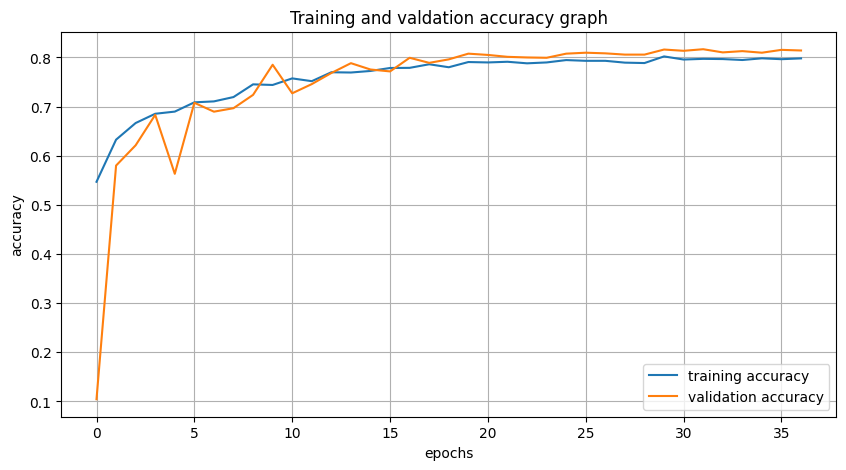

In [68]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label = "training accuracy")
plt.plot(history.history['val_accuracy'], label = "validation accuracy")

plt.title("Training and valdation accuracy graph")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

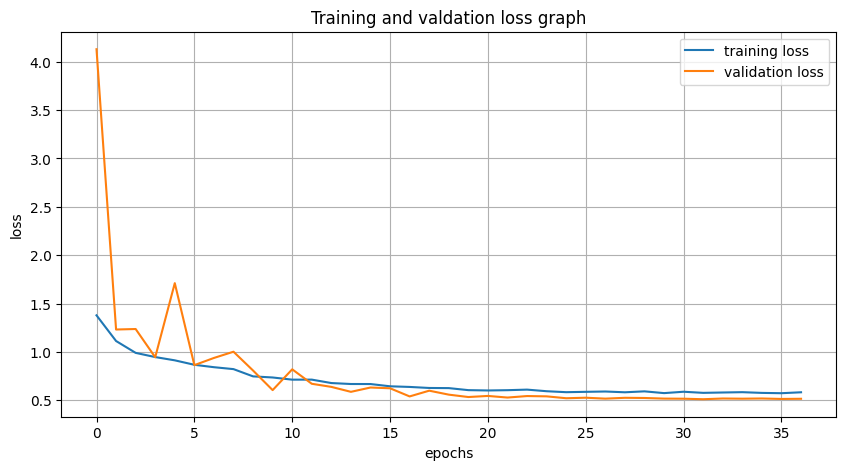

In [69]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label = "training loss")
plt.plot(history.history['val_loss'], label = "validation loss")

plt.title("Training and valdation loss graph")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
best_model = keras.models.load_model(
     "/kaggle/working/vehicle_color_model.h5"
)
print("model loaded")

model loaded


In [72]:
test_loss, test_accuracy = best_model.evaluate(test_ds)
print("Test loss : ", test_loss)
print("Test accuracy : ", test_accuracy)
print("Test accuracy in percentage : ", test_accuracy * 100)

49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7950 - loss: 0.5385
Test loss :  0.5385295152664185
Test accuracy :  0.794987142086029
Test accuracy in percentage :  79.4987142086029


In [74]:
y_true = []
y_predicted = []

for images, labels in test_ds :
    predictions = best_model.predict(images, verbose = 0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_predicted.extend(predicted_labels)

y_true = np.array(y_true)
y_predicted = np.array(y_predicted)

print("Total test samples:", len(y_true))

Total test samples: 1556


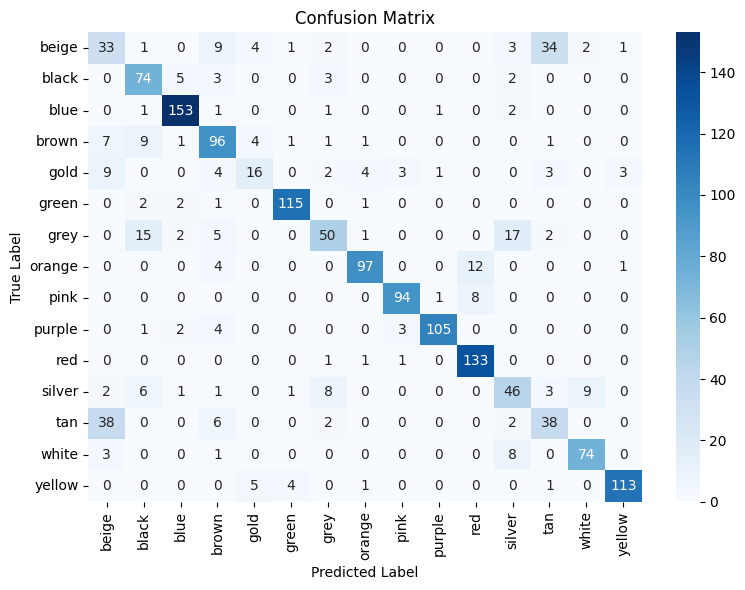

In [83]:
cm = confusion_matrix(y_true, y_predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [84]:
print(
    classification_report(
        y_true,
        y_predicted,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       beige       0.36      0.37      0.36        90
       black       0.68      0.85      0.76        87
        blue       0.92      0.96      0.94       159
       brown       0.71      0.79      0.75       121
        gold       0.55      0.36      0.43        45
       green       0.94      0.95      0.95       121
        grey       0.71      0.54      0.62        92
      orange       0.92      0.85      0.88       114
        pink       0.93      0.91      0.92       103
      purple       0.97      0.91      0.94       115
         red       0.87      0.98      0.92       136
      silver       0.57      0.60      0.59        77
         tan       0.46      0.44      0.45        86
       white       0.87      0.86      0.87        86
      yellow       0.96      0.91      0.93       124

    accuracy                           0.79      1556
   macro avg       0.76      0.75      0.75      1556
weighted avg       0.79   

In [ ]:
FINAL_MODEL_PATH = "/kaggle/working/vehicle_color_model.keras"

best_model.save(FINAL_MODEL_PATH)

print("Model saved successfully:")
print(FINAL_MODEL_PATH)

In [ ]:
import json

CLASS_NAMES_PATH = "/kaggle/working/class_names.json"

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f, indent=4)

print("Class mapping saved successfully:")
print(class_names)